# Recalibration model comparison: `global_median` vs `binned_median` vs `natural_cubic_spline`

Compares the three `fit_correction()` models (`searchops.recalibration`) fit on the
*same* `precursor_ppm`/`precursor_mz` data, across three precursor pools: the full
(unfiltered) run, `top_k_intense`, and `argmax_nms` -- one panel per pool, all three
model curves overlaid on that pool's own scatter.


In [1]:
import os
import subprocess
from pathlib import Path

# Notebook lives 3 levels under the repo root; jupyter/nbconvert default the kernel's cwd
# to the notebook's own directory, so resolve REPO_ROOT and chdir into it *before*
# importing searchops.recalibration below -- that module's dev/inspection block runs a
# cwd-relative file read at import time, which needs cwd == repo root to succeed.
REPO_ROOT = (Path.cwd() / "../../..").resolve()
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from searchops.recalibration import filter_top_psms, fit_correction

FDR = 0.01

# Fixed categorical order (Okabe-Ito, colorblind-safe) -- color follows the model,
# never rank, and stays consistent across every panel below.
MODEL_COLORS = {
    "global_median": "#E69F00",
    "binned_median": "#0072B2",
    "natural_cubic_spline": "#D55E00",
}

MODEL_CONFIGS = {
    "global_median": {"model": "global_median"},
    "binned_median": {"model": "binned_median", "bin_width_da": 10.0},
    "natural_cubic_spline": {"model": "natural_cubic_spline", "bin_width_da": 10.0},
}

PANEL_LABELS = {
    "full": "full (unfiltered)",
    "top_k_intense": "top_5000_intense",
    "argmax_nms": "argmax_nms (mz=5/rt=30/mob=0.02)",
    "argmax_nms_tight": "argmax_nms_tight (mz=2.5/rt=15/mob=0.01)",
}


## Resolve result paths via `./nf outputs` (not hardcoded node hashes)

Node hashes change if any upstream config/code changes, so paths are re-resolved from the
job TOMLs each time this notebook runs rather than pasted in as literals.


In [2]:
def nf_outputs(job_toml: str) -> dict[str, dict[str, str]]:
    """Parse `./nf outputs <job_toml>` into {combo_label: {output_name: result_path}}."""
    proc = subprocess.run(
        ["./nf", "outputs", job_toml],
        cwd=REPO_ROOT, capture_output=True, text=True, check=True,
    )
    combos: dict[str, dict[str, str]] = {}
    label = None
    for line in proc.stdout.splitlines():
        if not line.strip():
            continue
        if line.startswith("[") and line.endswith("]"):
            label = line[1:-1]
            combos[label] = {}
            continue
        key, rest = line.split("\t", 1)
        fields = dict(part.split("=", 1) for part in rest.split("\t"))
        combos[label][key] = fields["result"]
    return combos


def find_combo(combos: dict[str, dict[str, str]], suffix: str) -> dict[str, str]:
    """Exact `+<suffix>` match -- a plain substring check would also match
    "argmax_nms" inside "argmax_nms_tight"."""
    matches = [label for label in combos if label.endswith(f"+{suffix}")]
    assert len(matches) == 1, f"expected exactly one combo ending with +{suffix!r}, got {matches}"
    return combos[matches[0]]


# short_test.toml is the true unfiltered population; top_k_intense/argmax_nms are drawn
# from quick_test_10k_recal_grid's 10,000-capped pool.
baseline = nf_outputs("jobs/short_test.toml")["short_test"]
grid = nf_outputs("jobs/quick_test_10k_recal_grid.toml")

paths = {
    "full": REPO_ROOT / baseline["sage_results_tsv"],
    "top_k_intense": REPO_ROOT / find_combo(grid, "top_k_intense")["filtered_sage_results_tsv"],
    "argmax_nms": REPO_ROOT / find_combo(grid, "argmax_nms")["filtered_sage_results_tsv"],
    "argmax_nms_tight": REPO_ROOT / find_combo(grid, "argmax_nms_tight")["filtered_sage_results_tsv"],
}
paths


{'full': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/short_test/sage_results_tsv/results.sage.tsv'),
 'top_k_intense': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/quick_test_10k_recal_grid__recalibration_precursor_selection+top_k_intense/filtered_sage_results_tsv/results.sage.tsv'),
 'argmax_nms': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/quick_test_10k_recal_grid__recalibration_precursor_selection+argmax_nms/filtered_sage_results_tsv/results.sage.tsv'),
 'argmax_nms_tight': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/quick_test_10k_recal_grid__recalibration_precursor_selection+argmax_nms_tight/filtered_sage_results_tsv/results.sage.tsv')}

## Load confident PSMs from each pool

`filter_top_psms` (already used by `recalibrate()`) handles the `rank==1 & peptide_q<=fdr`
filter and adds the `precursor_mz` column.


In [3]:
dfs = {panel: filter_top_psms(path, fdr=FDR) for panel, path in paths.items()}
{panel: len(df) for panel, df in dfs.items()}


{'full': 78255,
 'top_k_intense': 3920,
 'argmax_nms': 623,
 'argmax_nms_tight': 1799}

## Join `neighbor_cnt` onto `argmax_nms`'s PSMs

`local_intensity_maxima_via_box_nms` now attaches `neighbor_cnt` -- the count of
candidates (including itself) inside each surviving point's own NMS box, previously
discarded -- to its output. That output is exactly what gets submitted to SAGE for the
recalibration branch (`select_recalibration_precursors` writes every column through
unchanged, and SAGE's `scannr` encodes the same `precursor_idx`), so join it back by
`precursor_idx` rather than re-deriving density from the (much sparser, post-search)
PSM set itself.


In [4]:
import re

import mmappet

for panel in ["argmax_nms", "argmax_nms_tight"]:
    precursors_path = REPO_ROOT / find_combo(grid, panel)["recalibration_precursors"]
    precursors = mmappet.open_dataset(precursors_path)[["precursor_idx", "neighbor_cnt"]]

    df = dfs[panel]
    precursor_idx = df["scannr"].str.extract(r"precursor_idx=(\d+)")[0].astype(np.int64)
    df = df.assign(precursor_idx=precursor_idx).merge(precursors, on="precursor_idx", how="left")
    assert df["neighbor_cnt"].notna().all(), f"every {panel} PSM must trace back to a submitted precursor"
    dfs[panel] = df

{panel: dfs[panel]["neighbor_cnt"].describe() for panel in ["argmax_nms", "argmax_nms_tight"]}


{'argmax_nms': count    623.000000
 mean      15.317817
             ...    
 75%       21.000000
 max       89.000000
 Name: neighbor_cnt, Length: 8, dtype: float64,
 'argmax_nms_tight': count    1799.000000
 mean        5.250695
             ...     
 75%         7.000000
 max        28.000000
 Name: neighbor_cnt, Length: 8, dtype: float64}

## Data + all three fitted correction curves, per pool

Each panel overlays the same pool's own `precursor_mz`/`precursor_ppm` scatter with all
three `fit_correction()` models fit on that same data -- so the panels compare pools,
and the curves within each panel compare models.


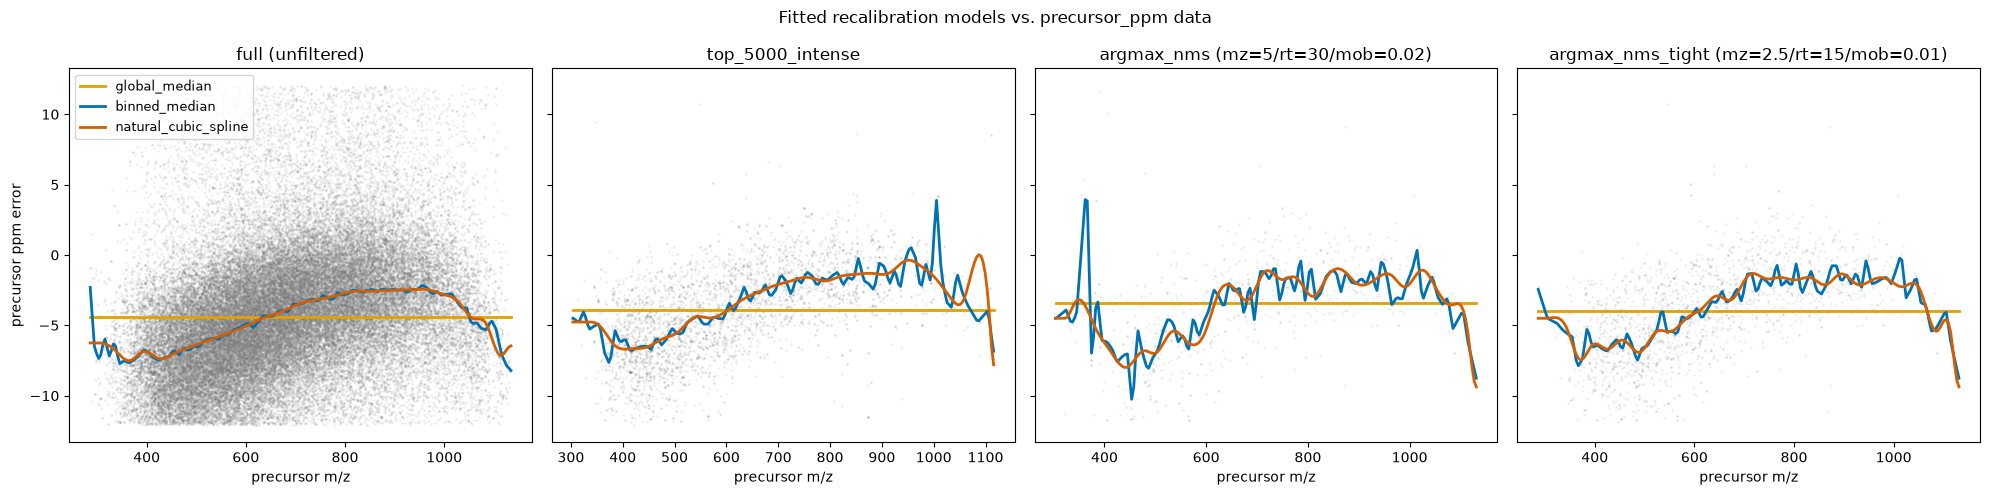

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, panel in zip(axes, ["full", "top_k_intense", "argmax_nms", "argmax_nms_tight"]):
    df = dfs[panel]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#808080", linewidths=0,
    )

    mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
    for model_name, config in MODEL_CONFIGS.items():
        correction = fit_correction(df, config)
        ax.plot(
            mz_line, correction(mz_line),
            color=MODEL_COLORS[model_name], linewidth=2, label=model_name,
        )

    ax.set_title(PANEL_LABELS[panel])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("Fitted recalibration models vs. precursor_ppm data")
fig.tight_layout()
plt.show()


## `natural_cubic_spline`: `bin_width_da` sweep

The default `bin_width_da=10.0` above produces a visibly wiggly curve -- `fit_correction`'s
only smoothness knob for this model is `bin_width_da` (wider bins -> fewer knots -> less
wiggle), so sweep it directly rather than changing the model.


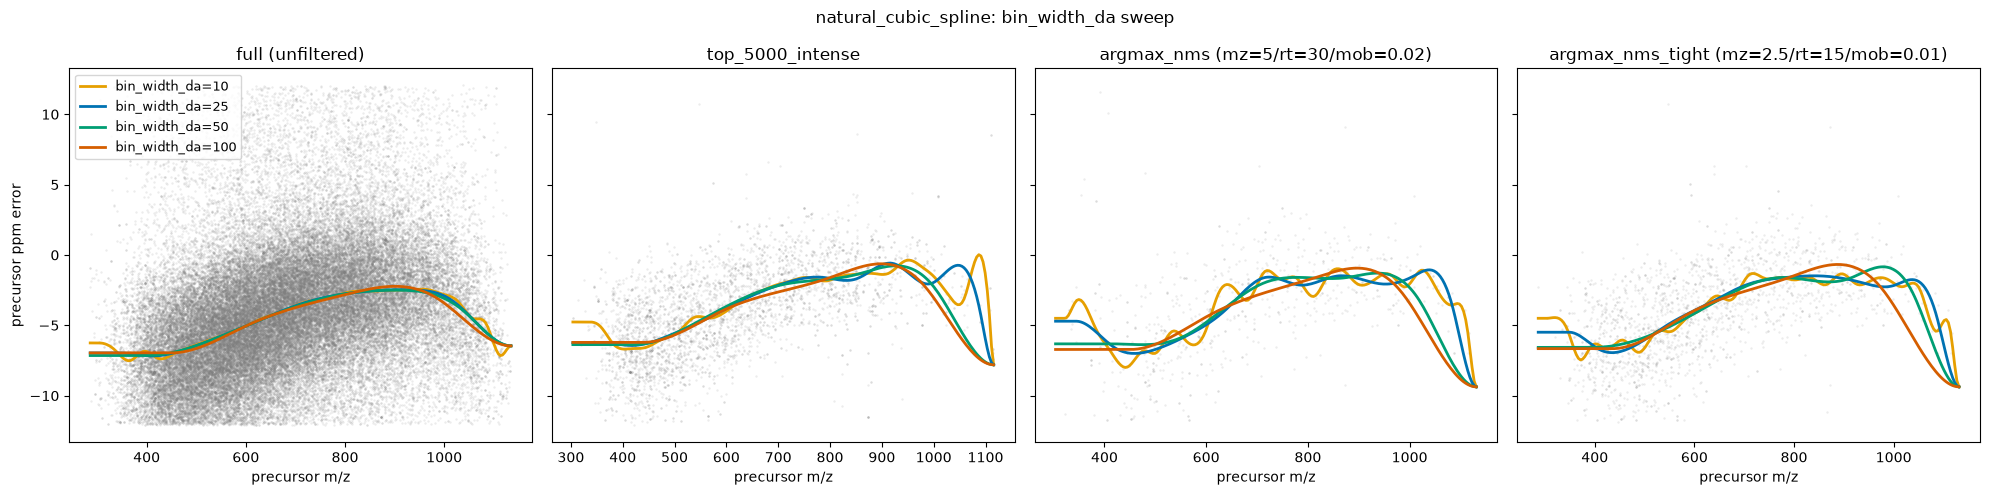

In [6]:
SWEEP_WIDTHS = [10, 25, 50, 100]
SWEEP_COLORS = dict(zip(SWEEP_WIDTHS, ["#E69F00", "#0072B2", "#009E73", "#D55E00"]))

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, panel in zip(axes, ["full", "top_k_intense", "argmax_nms", "argmax_nms_tight"]):
    df = dfs[panel]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#808080", linewidths=0,
    )

    mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
    for width in SWEEP_WIDTHS:
        correction = fit_correction(df, {"model": "natural_cubic_spline", "bin_width_da": width})
        ax.plot(
            mz_line, correction(mz_line),
            color=SWEEP_COLORS[width], linewidth=2, label=f"bin_width_da={width}",
        )

    ax.set_title(PANEL_LABELS[panel])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("natural_cubic_spline: bin_width_da sweep")
fig.tight_layout()
plt.show()


## Derivative-penalized smoother and an `xgboost` baseline

Two more candidate models, defined locally here (not added to `searchops/recalibration.py`
-- this is exploratory, not a production model):

- **`fit_derivative_penalized`**: same binned-median nodes as `binned_median`, but the node
  values are smoothed by penalizing the squared first-difference between adjacent nodes
  (a weighted order-1 Whittaker/P-spline smoother, closed-form via a tridiagonal solve --
  since nodes are evenly spaced this is approximately a penalty on the first derivative,
  as opposed to `natural_cubic_spline`'s implicit second-derivative smoothness). `lam`
  trades off fidelity to the raw per-bin medians (`lam=0`) against a flat slope
  (`lam -> inf`) -- picked by eye below, not swept.
- **`fit_xgboost`**: a gradient-boosted tree fit of `precursor_ppm ~ precursor_mz`, no
  smoothness assumption at all, as a nonparametric reference point.


In [7]:
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from xgboost import XGBRegressor


def fit_derivative_penalized(df: pd.DataFrame, config: dict):
    """Binned-median nodes, smoothed by penalizing the first difference between
    adjacent node values (~first derivative, since nodes are evenly spaced) --
    a weighted order-1 Whittaker/P-spline smoother, closed-form via a tridiagonal
    linear solve. `config["lam"]` trades off fidelity to the raw per-bin medians
    (lam=0) against a flat slope (lam -> inf); hand-tune by eye, not swept here.
    """
    mz = df["precursor_mz"].to_numpy()
    ppm = df["precursor_ppm"].to_numpy()
    bin_width = config["bin_width_da"]
    lam = config["lam"]

    bin_idx = np.floor(mz / bin_width).astype(np.int64)
    grouped = (
        pd.DataFrame({"bin": bin_idx, "ppm": ppm})
        .groupby("bin")["ppm"]
        .agg(["median", "count"])
        .sort_index()
    )
    node_mz = (grouped.index.to_numpy() + 0.5) * bin_width
    y = grouped["median"].to_numpy()
    w = grouped["count"].to_numpy().astype(np.float64)

    n = len(y)
    D = diags([-np.ones(n - 1), np.ones(n - 1)], offsets=[0, 1], shape=(n - 1, n))
    A = diags(w) + lam * (D.T @ D)
    f = spsolve(A.tocsc(), w * y)

    return lambda mz: np.interp(mz, node_mz, f)


def fit_xgboost(df: pd.DataFrame, config: dict):
    """Gradient-boosted regression tree fit of precursor_ppm ~ precursor_mz --
    a nonparametric baseline with no smoothness assumption baked in."""
    model = XGBRegressor(
        n_estimators=config.get("n_estimators", 200),
        max_depth=config.get("max_depth", 3),
        learning_rate=config.get("learning_rate", 0.05),
        reg_lambda=config.get("reg_lambda", 1.0),
    )
    mz = df["precursor_mz"].to_numpy().reshape(-1, 1)
    ppm = df["precursor_ppm"].to_numpy()
    model.fit(mz, ppm)
    return lambda mz: model.predict(np.asarray(mz, dtype=np.float64).reshape(-1, 1))


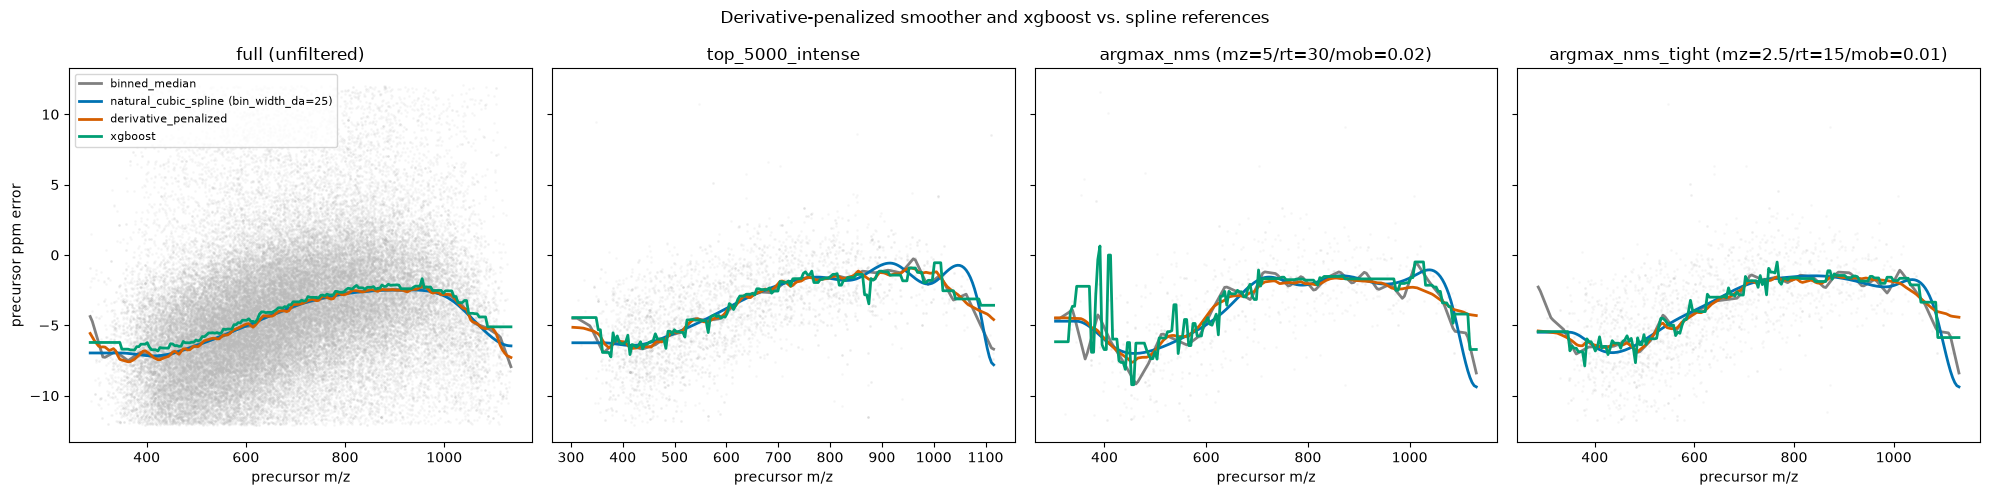

In [8]:
COMPARE_COLORS = {
    "binned_median": "#808080",
    "natural_cubic_spline (bin_width_da=25)": "#0072B2",
    "derivative_penalized": "#D55E00",
    "xgboost": "#009E73",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, panel in zip(axes, ["full", "top_k_intense", "argmax_nms", "argmax_nms_tight"]):
    df = dfs[panel]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=3, alpha=0.15, color="#bbbbbb", linewidths=0,
    )

    mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
    curves = {
        "binned_median": fit_correction(df, {"model": "binned_median", "bin_width_da": 25.0}),
        "natural_cubic_spline (bin_width_da=25)": fit_correction(
            df, {"model": "natural_cubic_spline", "bin_width_da": 25.0}
        ),
        "derivative_penalized": fit_derivative_penalized(df, {"bin_width_da": 10.0, "lam": 50.0}),
        "xgboost": fit_xgboost(df, {}),
    }
    for name, correction in curves.items():
        ax.plot(mz_line, correction(mz_line), color=COMPARE_COLORS[name], linewidth=2, label=name)

    ax.set_title(PANEL_LABELS[panel])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=8, loc="best")
fig.suptitle("Derivative-penalized smoother and xgboost vs. spline references")
fig.tight_layout()
plt.show()


## All 5 models, one panel each, pools overlaid

Transposes the earlier layout: instead of one panel per pool (with models overlaid),
one panel per model category here, each overlaying the 3 pools (`full`,
`top_k_intense`, `argmax_nms`) as curves -- so this reads as "how much do the pools
disagree, for a given model," rather than "how much do the models disagree, for a
given pool." No scatter (3 overlaid pools' raw points would be noisy); curves only.
`binned_median`/`natural_cubic_spline` use `bin_width_da=25.0` (the sweep's middling
pick); `derivative_penalized` uses the same `bin_width_da=10.0, lam=50.0` as before.


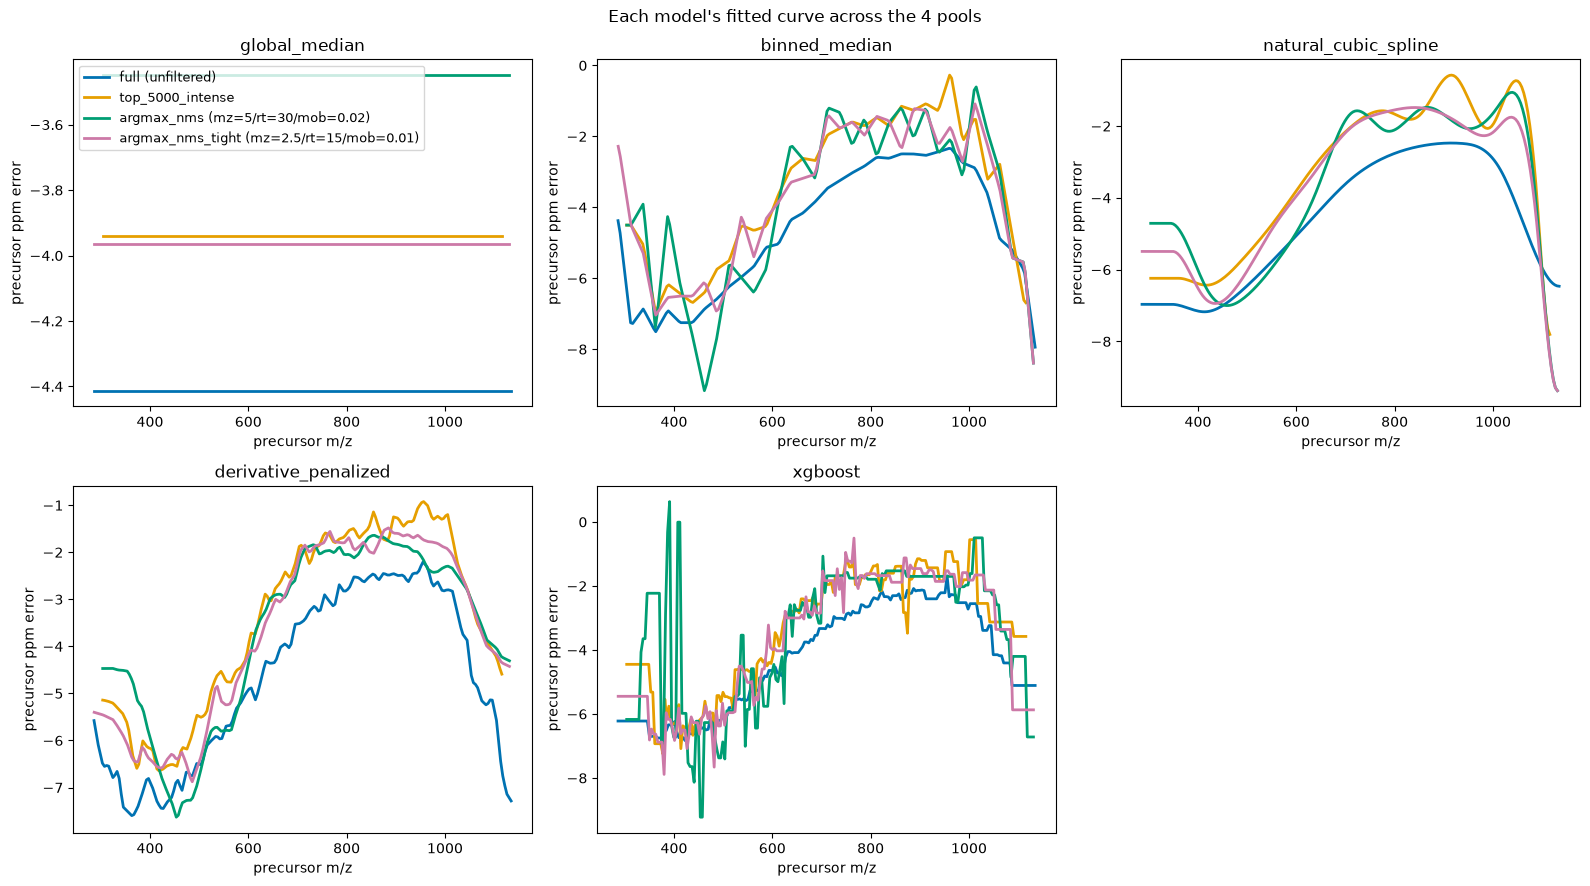

In [9]:
POOL_COLORS = {
    "full": "#0072B2",
    "top_k_intense": "#E69F00",
    "argmax_nms": "#009E73",
    "argmax_nms_tight": "#CC79A7",
}

MODEL_PANELS = {
    "global_median": lambda df: fit_correction(df, {"model": "global_median"}),
    "binned_median": lambda df: fit_correction(df, {"model": "binned_median", "bin_width_da": 25.0}),
    "natural_cubic_spline": lambda df: fit_correction(
        df, {"model": "natural_cubic_spline", "bin_width_da": 25.0}
    ),
    "derivative_penalized": lambda df: fit_derivative_penalized(
        df, {"bin_width_da": 10.0, "lam": 50.0}
    ),
    "xgboost": lambda df: fit_xgboost(df, {}),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (model_name, fit_fn) in zip(axes, MODEL_PANELS.items()):
    for panel in ["full", "top_k_intense", "argmax_nms", "argmax_nms_tight"]:
        df = dfs[panel]
        mz_line = np.linspace(df["precursor_mz"].min(), df["precursor_mz"].max(), 200)
        correction = fit_fn(df)
        ax.plot(
            mz_line, correction(mz_line),
            color=POOL_COLORS[panel], linewidth=2, label=PANEL_LABELS[panel],
        )
    ax.set_title(model_name)
    ax.set_xlabel("precursor m/z")
    ax.set_ylabel("precursor ppm error")

axes[-1].axis("off")
axes[0].legend(fontsize=9, loc="best")
fig.suptitle("Each model's fitted curve across the 4 pools")
fig.tight_layout()
plt.show()


## Unweighted vs. `neighbor_cnt`-weighted fit, default vs. tight radii (argmax_nms)

`argmax_nms` is the only pool with a real density signal (`top_k_intense` is a global
rank cut, `non_overlap`'s grid-cell occupancy isn't captured yet) -- weight each
surviving PSM by how many candidates its own NMS box suppressed, so a survivor that
stood in for a crowded neighborhood counts for more than one that was already
isolated. `fit_correction`'s `weights` argument leaves every other call in this
notebook (and `recalibrate()` itself) untouched -- passing `weights=None` (the
default) reproduces the exact unweighted curves fit earlier.

Also compares the default NMS radii (`mz_radius_da=5.0, rt_radius_s=30.0,
mobility_radius=0.02`) against half those radii (`argmax_nms_tight`, `jobs/quick_test_10k_recal_grid.toml`)
-- smaller neighborhoods mean fewer candidates get suppressed per surviving point, so
more of the underlying cloud survives (730 -> 2235 PSMs here) at the cost of `neighbor_cnt`
itself shrinking (denser boxes now split across more survivors instead of collapsing
into one).


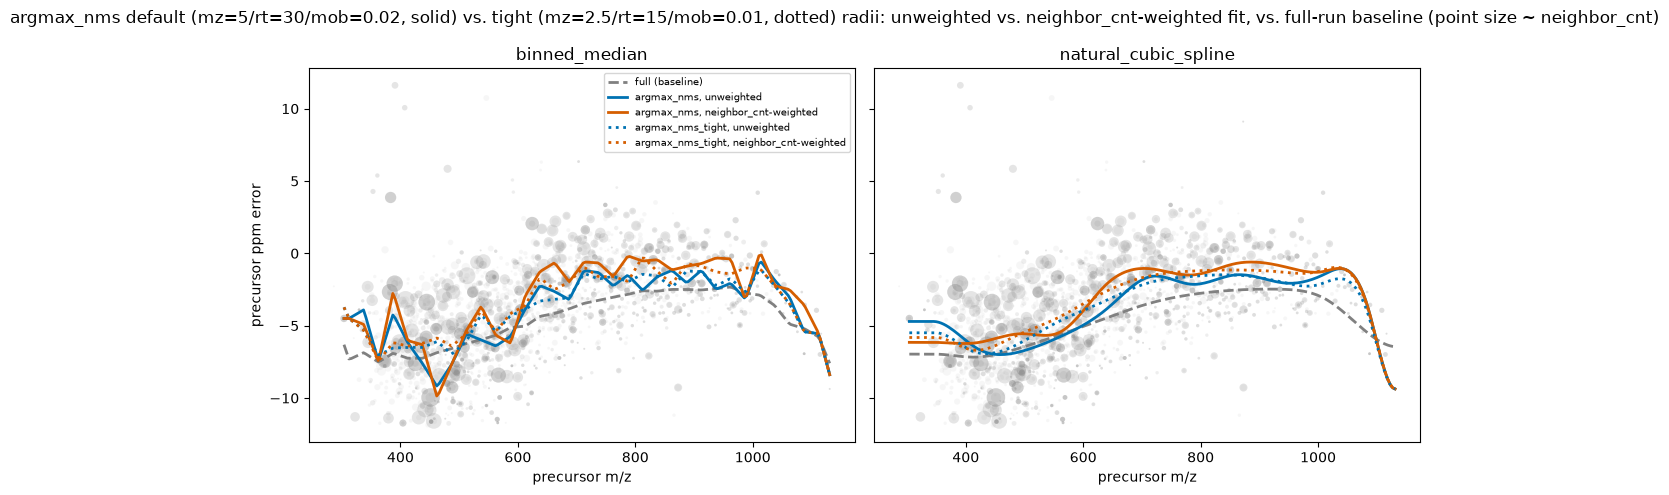

In [10]:
argmax_df = dfs["argmax_nms"]
argmax_tight_df = dfs["argmax_nms_tight"]
full_df_ref = dfs["full"]
argmax_weights = argmax_df["neighbor_cnt"].to_numpy(dtype=np.float64)
argmax_tight_weights = argmax_tight_df["neighbor_cnt"].to_numpy(dtype=np.float64)
mz_line = np.linspace(argmax_df["precursor_mz"].min(), argmax_df["precursor_mz"].max(), 200)

WEIGHT_CONFIGS = {
    "binned_median": {"model": "binned_median", "bin_width_da": 25.0},
    "natural_cubic_spline": {"model": "natural_cubic_spline", "bin_width_da": 25.0},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (model_name, config) in zip(axes, WEIGHT_CONFIGS.items()):
    # tight window is denser (more survivors) -- draw it first, underneath
    ax.scatter(
        argmax_tight_df["precursor_mz"], argmax_tight_df["precursor_ppm"],
        s=argmax_tight_df["neighbor_cnt"] * 2, alpha=0.12, color="#bbbbbb", linewidths=0,
    )
    ax.scatter(
        argmax_df["precursor_mz"], argmax_df["precursor_ppm"],
        s=argmax_df["neighbor_cnt"] * 2, alpha=0.2, color="#808080", linewidths=0,
    )

    full_baseline = fit_correction(full_df_ref, config)
    unweighted = fit_correction(argmax_df, config)
    weighted = fit_correction(argmax_df, config, weights=argmax_weights)
    tight_unweighted = fit_correction(argmax_tight_df, config)
    tight_weighted = fit_correction(argmax_tight_df, config, weights=argmax_tight_weights)

    ax.plot(
        mz_line, full_baseline(mz_line),
        color="#808080", linewidth=2, linestyle="--", label="full (baseline)",
    )
    ax.plot(
        mz_line, unweighted(mz_line),
        color="#0072B2", linewidth=2, linestyle="-", label="argmax_nms, unweighted",
    )
    ax.plot(
        mz_line, weighted(mz_line),
        color="#D55E00", linewidth=2, linestyle="-", label="argmax_nms, neighbor_cnt-weighted",
    )
    ax.plot(
        mz_line, tight_unweighted(mz_line),
        color="#0072B2", linewidth=2, linestyle=":", label="argmax_nms_tight, unweighted",
    )
    ax.plot(
        mz_line, tight_weighted(mz_line),
        color="#D55E00", linewidth=2, linestyle=":", label="argmax_nms_tight, neighbor_cnt-weighted",
    )

    ax.set_title(model_name)
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
axes[0].legend(fontsize=7, loc="best")
fig.suptitle(
    "argmax_nms default (mz=5/rt=30/mob=0.02, solid) vs. tight (mz=2.5/rt=15/mob=0.01, dotted) "
    "radii: unweighted vs. neighbor_cnt-weighted fit, vs. full-run baseline "
    "(point size ~ neighbor_cnt)"
)
fig.tight_layout()
plt.show()
